# TimeSeries analysis and modelling

In [1]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.api import datasets

from nescience.timeseries import TimeSeries

## Auto-miscoding

Load sample data: Mauna Loa Weekly Atmospheric CO2 Data.

In [2]:
co2  = datasets.co2.load_pandas()
data = co2.data.dropna(axis=0).values.flatten()

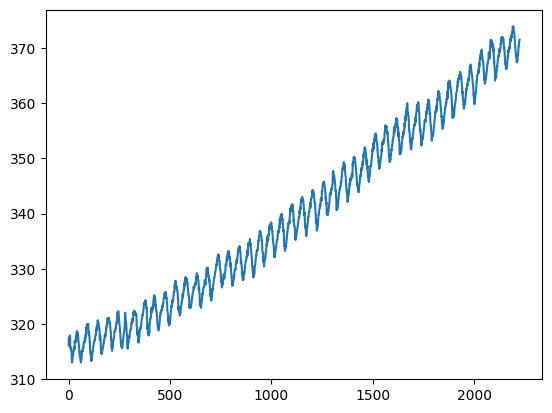

In [3]:
plt.plot(data)
plt.show()

Next code computes a classical auto-correlogram for this time series.

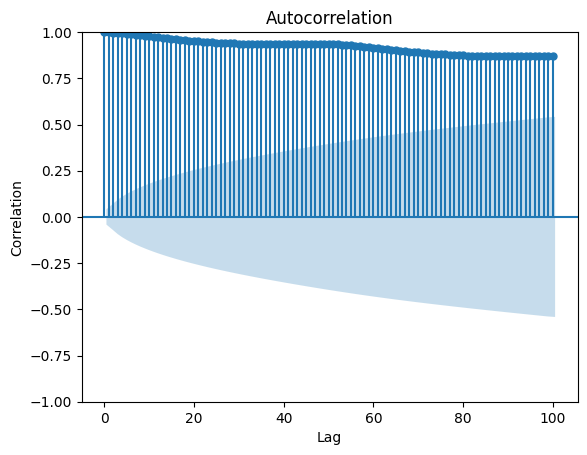

In [4]:
plot_acf(data, lags=100)
plt.title("Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.show()

Auto-correlation is not defined in case of non-stationary time series.

Let see how auto-miscoding applies to the same time series:

In [5]:
ts = TimeSeries(
    window_size=24,
    max_lag=100,
    models=("autoregressive", "moving_average", "exponential_smoothing"),
    validation="holdout",
    test_size=0.25,
    n_bins="auto",
)
ts.fit(data)

lags = ts.auto_lag_analysis(max_lag=100)

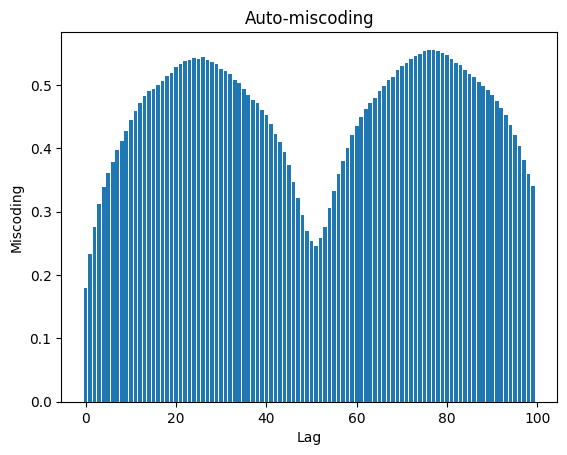

In [6]:
plt.bar(x=np.arange(len(lags["deficiency"])), height=lags["miscoding"])
plt.xlabel("Lag")
plt.ylabel("Miscoding")
plt.title("Auto-miscoding")
plt.show()

Automiscoding can work with non-stationary time series, and has successfully detected the seasonal component.

## Cross-Miscoding

Load sample data: US Macroeconomic Data for 1959Q1 - 2009Q3.

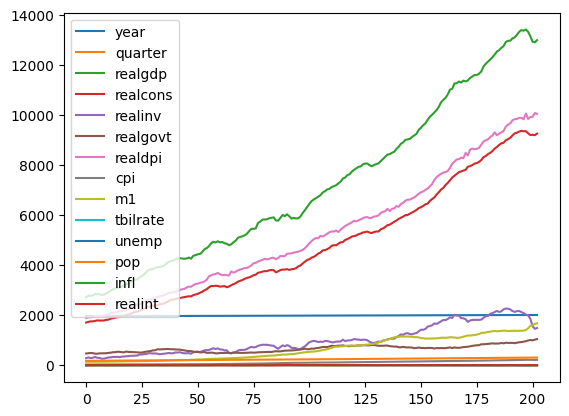

In [7]:
mdata = datasets.macrodata.load_pandas().data
mdata.plot()
plt.show()

We want to identify which are the attributes that have a higher (temporal) predictive power over the unemployment.

In [8]:
mdata = mdata.drop(["year", "quarter"], axis=1)
y = mdata["unemp"]
X = mdata.drop(["unemp"], axis=1)


In [9]:
# Fit the new TimeSeries object
ts = TimeSeries(
    X_type="numeric",
    y_type="numeric",
    auto=False,
    window_size="auto",
    max_lag=50,
)
ts.fit(y, X)
lag_table = ts.cross_lag_analysis(attribute=0, max_lag=50)

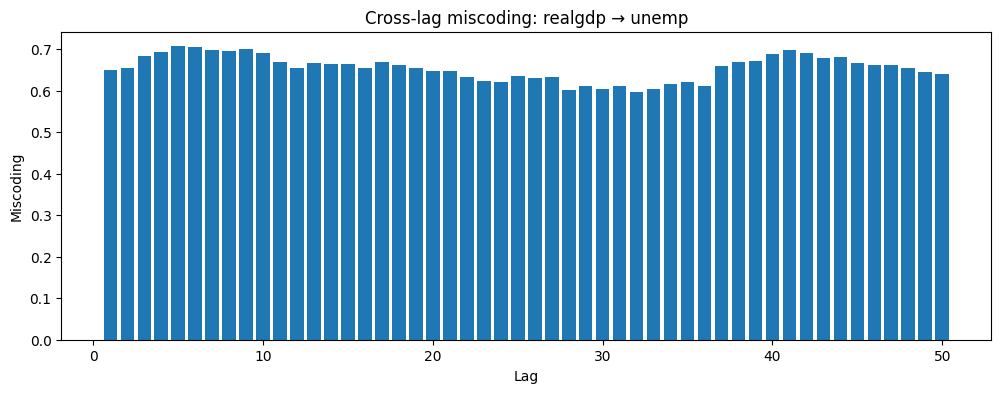

In [10]:
# Plot lag miscoding
plt.figure(figsize=(12, 4))
plt.bar(x=lag_table["lag"], height=lag_table["miscoding"])
plt.xlabel("Lag")
plt.ylabel("Miscoding")
plt.title(f"Cross-lag miscoding: {lag_table['attribute'].iloc[0]} → unemp")
plt.show()

In [11]:
lag_table = ts.cross_lag_analysis(attribute=3, max_lag=50)

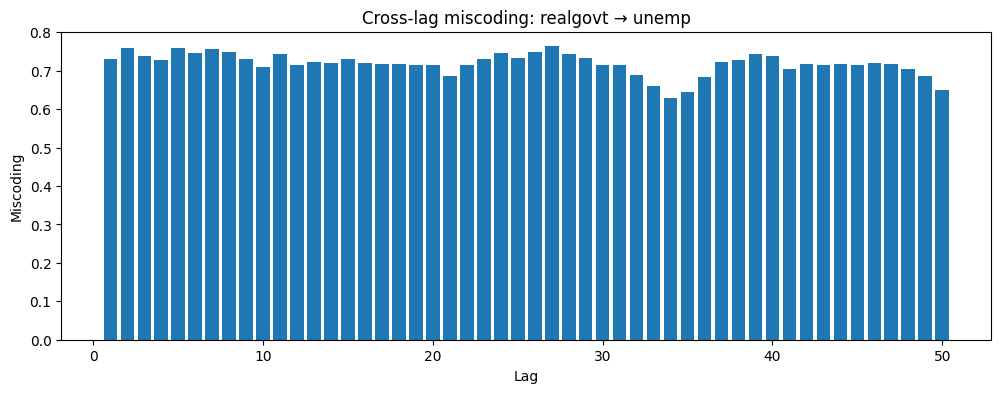

In [12]:
# Plot lag miscoding
plt.figure(figsize=(12, 4))
plt.bar(x=lag_table["lag"], height=lag_table["miscoding"])
plt.xlabel("Lag")
plt.ylabel("Miscoding")
plt.title(f"Cross-lag miscoding: {lag_table['attribute'].iloc[0]} → unemp")
plt.show()

In the short term, it seems that "realgdp" has a higher predictive power than "realgovt".

### Forecasting

Naive target goal against we can compare.

In [13]:
def dummy_score(ts):
    mean = np.mean(ts)
    u = np.sum([(ts[i] - ts[i-1])**2 for i in range(0, len(ts)-1)])
    v = np.sum([(ts[i] - mean)**2 for i in range(0, len(ts)-1)])
    score = 1 - u/v
    return score

Load sample data: World Copper Market 1951-1975 Dataset

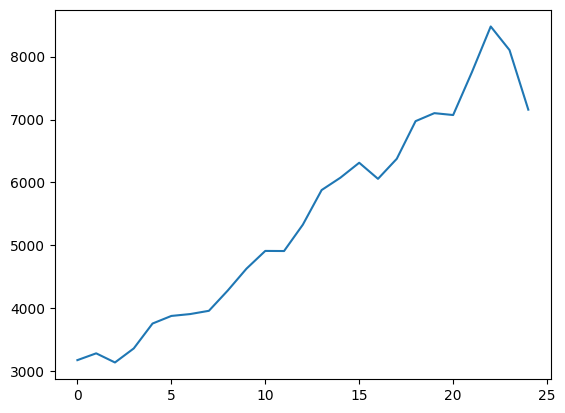

In [14]:
data = datasets.copper.load_pandas().data
copper = data["WORLDCONSUMPTION"]
copper.plot()
plt.show()

In [15]:
dummy_score(np.array(copper))

np.float64(0.7077162085429185)

In [16]:
model = TimeSeries()
model.fit(copper)
model.score(copper)

0.936030246262495

In [17]:
type(model.get_model())

sklearn.linear_model._base.LinearRegression

### Rolling nescience: detecting regime change

The class itself does not need a special regime-change algorithm. We can fit the same nescience-based time-series model over rolling windows.

This example creates a series with two regimes:

1. an AR(1) process;
2. white noise.

The transition should increase deficiency, because past values stop explaining the future.

In [18]:
rng = np.random.default_rng(99)

n1 = 500
n2 = 500

regime_1 = np.zeros(n1)
noise_1 = rng.normal(scale=0.4, size=n1)

for i in range(1, n1):
    regime_1[i] = 0.85 * regime_1[i - 1] + noise_1[i]

regime_2 = rng.normal(scale=np.std(regime_1), size=n2)

y_regime = np.concatenate([regime_1, regime_2])

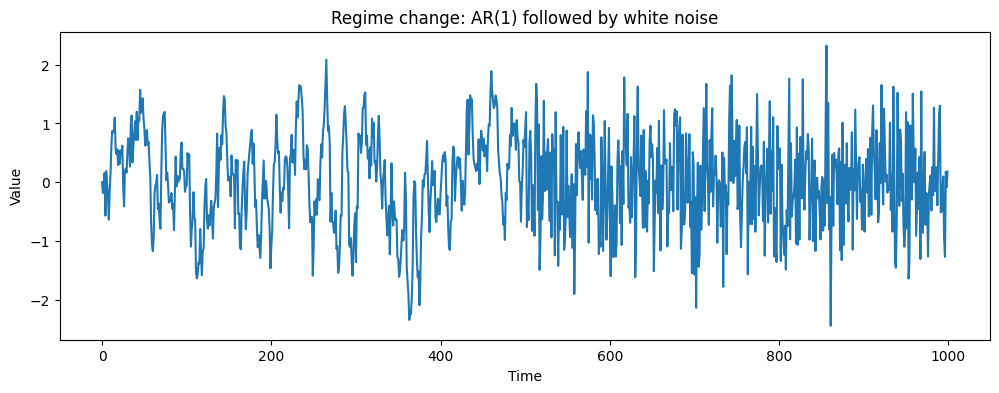

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y_regime)), y_regime)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Regime change: AR(1) followed by white noise")
plt.show()

In [20]:
window = 220
step = 40

rolling_rows = []

for start in range(0, len(y_regime) - window + 1, step):
    end = start + window
    y_window = y_regime[start:end]

    ts_window = TimeSeries(
        window_size=24,
        max_lag=24,
        models=("autoregressive",),
        validation="holdout",
        test_size=0.25,
        n_bins="auto",
    )
    ts_window.fit(y_window)
    explanation = ts_window.explain()

    rolling_rows.append({
        "start": start,
        "end": end,
        "center": (start + end) // 2,
        "nescience": explanation["nescience"],
        **explanation["components"],
        "dominant_component": explanation["dominant_component"],
        "n_features_in_use": explanation["n_features_in_use"],
    })

rolling = pd.DataFrame(rolling_rows)

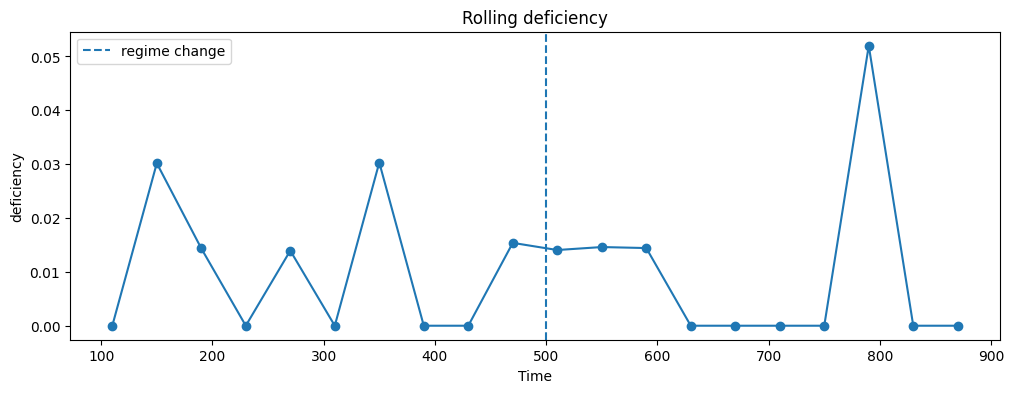

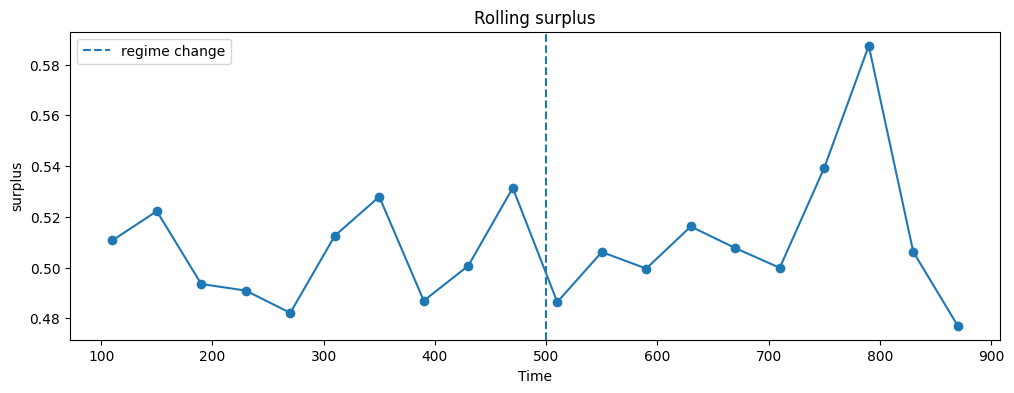

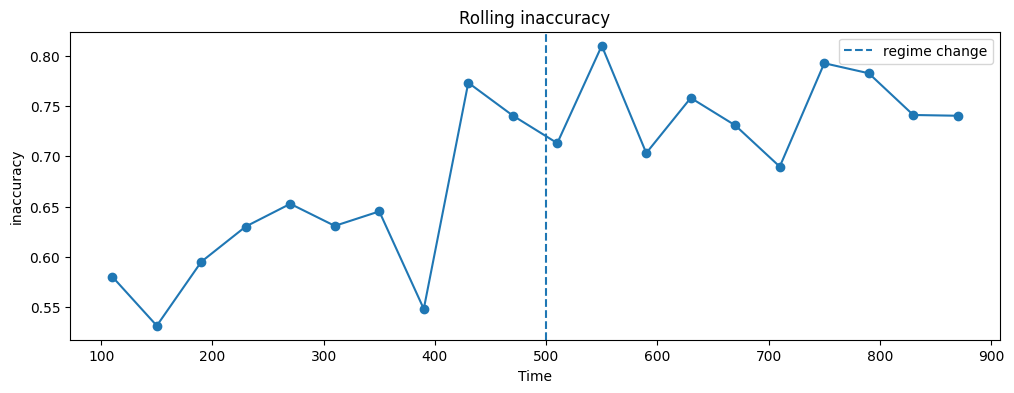

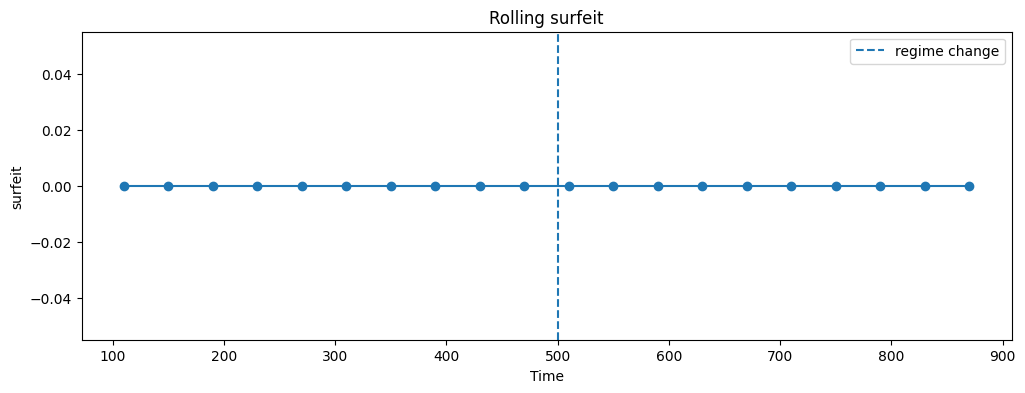

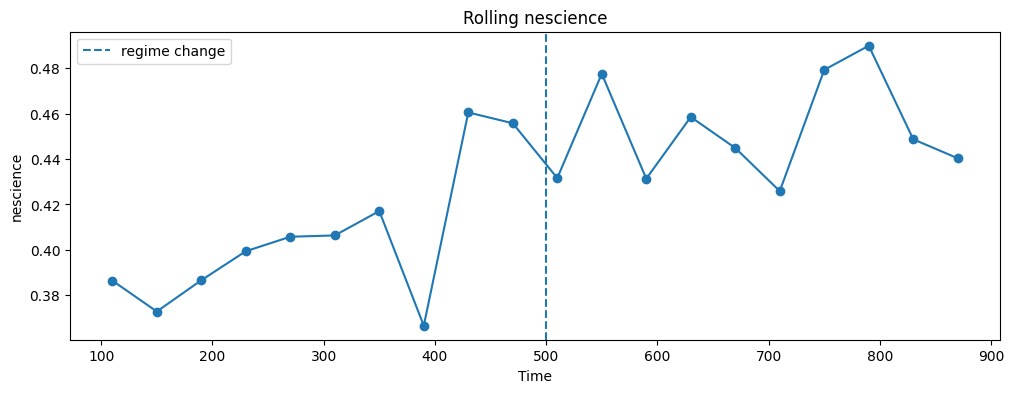

In [21]:
for column in ["deficiency", "surplus", "inaccuracy", "surfeit", "nescience"]:
    plt.figure(figsize=(12, 4))
    plt.plot(rolling["center"], rolling[column], marker="o")
    plt.axvline(n1, linestyle="--", label="regime change")
    plt.xlabel("Time")
    plt.ylabel(column)
    plt.title(f"Rolling {column}")
    plt.legend()
    plt.show()

Expected interpretation:

- Before the change point, past lags should explain part of the future.
- After the change point, deficiency should increase because the process becomes closer to memoryless noise.
- This is a strong use case for nescience: it can diagnose when the temporal representation stops being informative.